# Monster taming and battling, part 1: creatures, types and battles
* welcome to a brand new mini game-dev arc! over the next two lessons we build our own small, completely original "collect creatures and battle them" game - you know the genre: little critters with elemental types, you catch them in the wild, you build a team, and you battle other trainers turn by turn
* to be crystal clear: everything in here is our OWN invented content - our own creature names, our own move names, our own type system. no trademarked species or moves anywhere, this is just us implementing the GENRE's mechanics from scratch, the same way lesson 32 built its own tiny original RPG
* this lesson (part 1) builds the DATA and BATTLE MECHANICS half: a creature data model, an elemental type-effectiveness chart, a turn-based battle system with selectable moves and a status effect, and a catching mechanic
* lesson 38 (part 2, written right after this one) builds the OTHER half on top of what we make here: walking around an overworld, running into wild creatures, and battling other trainers - so we keep our classes clean and reusable, even though this notebook is fully self-contained on its own
* quick recap of lesson 32's battle system, and the three things we add on top of it here:
  1. lesson 32 had no TYPES at all - every hit was just `attack - defense`. we add elemental TYPES (fire/water/grass/normal) and a type-effectiveness chart, so the same move deals different damage depending on what it hits
  2. lesson 32's player could only ever do a generic "attack" - we add actual selectable MOVES, each with their own type, power and accuracy, and creatures can know up to 4 of them
  3. lesson 32 only had "win the fight or lose the fight" - we add a CATCHING mechanic, a whole third way a battle can end
* we also fix a `random.seed()` right at the top, same as lesson 32 - randomness only shows up in small damage variance, catch attempts and status effect rolls, and a fixed seed means this notebook produces the EXACT same battle every single time you run it

## setup (recap lesson 27's headless pygame trick)
* same dummy video/audio driver setup as every lesson in the game-dev arc, and the same `show_surface()` helper to render a pygame `Surface` inline in the notebook
* we fix the random seed immediately, before we do anything else that could possibly call `random` - that way literally everything below is 100% reproducible

In [1]:
import os

# these two env vars MUST be set before "import pygame" happens - recap lesson 27, this is the headless/off-screen trick
os.environ["SDL_VIDEODRIVER"] = "dummy"   # render into memory only, no real window (this notebook runs on a server)
os.environ["SDL_AUDIODRIVER"] = "dummy"   # no real sound card here either, we dont use sound in this lesson anyway

import pygame
import numpy as np
import matplotlib.pyplot as plt
import random  # used for damage variance, move accuracy rolls, status effect chance rolls and catch attempts
from dataclasses import dataclass  # recap lesson 10 - our species/move data records
from enum import Enum  # recap lesson 10 - our small, fixed set of elemental types

pygame.init()
pygame.font.init()  # the battle screen at the end uses pygame.font for names/hp/type labels


def show_surface(surface, title=None, figsize=(5, 4)):
    """Render a pygame Surface inline in the notebook (recap lesson 27)."""
    pixel_array = pygame.surfarray.array3d(surface).swapaxes(0, 1)
    plt.figure(figsize=figsize)
    plt.imshow(pixel_array)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()


random.seed(42)  # fixed seed - EVERY random call below (damage swing, accuracy, status, catches) is now reproducible

screen = pygame.display.set_mode((320, 240))  # one shared "screen" surface, reused for every battle screenshot below
font = pygame.font.SysFont(None, 18)  # small built-in font for names/hp/type text on the battle screen

print("pygame ready, screen is", screen.get_size(), "- lets build our creature-battling game")

pygame 2.6.1 (SDL 2.28.4, Python 3.11.15)
Hello from the pygame community. https://www.pygame.org/contribute.html


pygame ready, screen is (320, 240) - lets build our creature-battling game


## elemental types and the effectiveness chart
* every creature and every move belongs to one of a SMALL set of elemental types - we keep this list short (4 types to start, we add a 5th one ourselves in the exercises) so the chart stays easy to reason about
* we use an `Enum` for this (recap lesson 10) instead of plain strings - `ElementType.FIRE` is way harder to typo than `"fire"`, and we can iterate over every type easily
* the effectiveness CHART is just a `dict` of `dict`s: `TYPE_CHART[attacking_type][defending_type]` gives us the damage multiplier. we only bother listing the INTERESTING relationships (2x "super effective" and 0.5x "not very effective") - anything not listed simply defaults to a normal 1x, which our lookup function handles for us
* our little type triangle: fire beats grass, grass beats water, water beats fire (classic rock-paper-scissors shape) - `normal` is deliberately boring, it has no strengths or weaknesses at all, which is a genre convention too

In [2]:
class ElementType(Enum):
    """Our small, fixed set of elemental types. Kept deliberately short - more types = a much bigger chart to design."""
    FIRE = "fire"
    WATER = "water"
    GRASS = "grass"
    NORMAL = "normal"  # the "no special strengths or weaknesses" type - every attack against/from it is just 1x


# TYPE_CHART[attacking_type][defending_type] = damage multiplier. anything missing here just means "1x, nothing special"
TYPE_CHART: dict[ElementType, dict[ElementType, float]] = {
    ElementType.FIRE: {ElementType.GRASS: 2.0, ElementType.WATER: 0.5},   # fire torches grass, fizzles against water
    ElementType.WATER: {ElementType.FIRE: 2.0, ElementType.GRASS: 0.5},   # water douses fire, grass soaks it up
    ElementType.GRASS: {ElementType.WATER: 2.0, ElementType.FIRE: 0.5},   # grass drinks up water, fire burns it away
    ElementType.NORMAL: {},  # normal has no listed relationships at all - always exactly 1x, both attacking and defending
}


def type_effectiveness(attacking_type: ElementType, defending_type: ElementType) -> float:
    """Look up the damage multiplier for one type attacking another. Falls back to a normal 1x if unlisted."""
    # .get(attacking_type, {}) -> that attacker's row, or an empty dict if the attacker has no special relationships at all
    # .get(defending_type, 1.0) -> that specific matchup's multiplier, or 1.0 (normal) if this exact pair isnt listed
    return TYPE_CHART.get(attacking_type, {}).get(defending_type, 1.0)


# a few quick sanity checks, so we can see the chart working before we build anything on top of it
print("fire vs grass:  ", type_effectiveness(ElementType.FIRE, ElementType.GRASS), "(super effective)")
print("fire vs water:  ", type_effectiveness(ElementType.FIRE, ElementType.WATER), "(not very effective)")
print("fire vs normal: ", type_effectiveness(ElementType.FIRE, ElementType.NORMAL), "(just normal, unlisted pair)")
print("normal vs normal:", type_effectiveness(ElementType.NORMAL, ElementType.NORMAL), "(normal is always boring)")

fire vs grass:   2.0 (super effective)
fire vs water:   0.5 (not very effective)
fire vs normal:  1.0 (just normal, unlisted pair)
normal vs normal: 1.0 (normal is always boring)


## creature species and moves (recap `@dataclass`, lesson 10)
* `CreatureSpecies` describes a KIND of creature (like a blueprint) - its name, its type, and its base stats. its just data, no behaviour, so its a perfect `@dataclass` (recap lesson 32's `Item`)
* `Move` describes one attack a creature can know - its own type (for effectiveness purposes, which does NOT have to match the user's type!), how much `power` it hits for, an `accuracy` (0.0-1.0 chance it actually connects) and an OPTIONAL `status_effect` it might inflict on top of the damage
* we keep our starting roster to 4 species across 4 types, each an entirely original, generic little creature - and a small movepool of original moves to go with them

In [3]:
@dataclass
class CreatureSpecies:
    """A blueprint for a KIND of creature (not a specific battling instance - see the Creature class further down)."""
    name: str
    element_type: ElementType
    base_hp: int
    base_attack: int
    base_defense: int
    base_speed: int  # higher speed acts first in battle - see determine_turn_order() later on


@dataclass
class Move:
    """One attack a creature can know. move_type is used for type-effectiveness, independent of the user's own type."""
    name: str
    move_type: ElementType
    power: int                       # how hard this move hits, before type effectiveness/defense are applied
    accuracy: float                  # 0.0-1.0 chance the move actually connects at all
    status_effect: str | None = None  # e.g. "paralysis" - None means this move never inflicts a status
    status_chance: float = 0.0       # 0.0-1.0 chance of inflicting status_effect, only relevant if status_effect is set


# our original starting roster - 4 small, generic, clearly-not-trademarked creatures, one per type
EMBERLING = CreatureSpecies("Emberling", ElementType.FIRE, base_hp=95, base_attack=38, base_defense=32, base_speed=65)
AQUALING = CreatureSpecies("Aqualing", ElementType.WATER, base_hp=100, base_attack=34, base_defense=38, base_speed=50)
LEAFLET = CreatureSpecies("Leaflet", ElementType.GRASS, base_hp=105, base_attack=33, base_defense=40, base_speed=45)
ROCKLING = CreatureSpecies("Rockling", ElementType.NORMAL, base_hp=115, base_attack=30, base_defense=52, base_speed=30)

# our original movepool - notice the moves are all fairly weak on paper, base_hp values above are deliberately
# on the larger side so battles play out over several rounds instead of ending in a single hit (more fun to follow!)
EMBER = Move("Ember", ElementType.FIRE, power=22, accuracy=0.95)
AQUA_JET = Move("Aqua Jet", ElementType.WATER, power=22, accuracy=0.95)
VINE_WHIP = Move("Vine Whip", ElementType.GRASS, power=22, accuracy=0.95)
TACKLE = Move("Tackle", ElementType.NORMAL, power=16, accuracy=1.0)  # a weak but always-normal, always-accurate fallback
NUMBING_SPORES = Move("Numbing Spores", ElementType.GRASS, power=14, accuracy=0.85,
                       status_effect="paralysis", status_chance=0.45)  # weak damage, but a real chance to paralyze

for species in (EMBERLING, AQUALING, LEAFLET, ROCKLING):
    print(species)
print()
for move in (EMBER, AQUA_JET, VINE_WHIP, TACKLE, NUMBING_SPORES):
    print(move)

CreatureSpecies(name='Emberling', element_type=<ElementType.FIRE: 'fire'>, base_hp=95, base_attack=38, base_defense=32, base_speed=65)
CreatureSpecies(name='Aqualing', element_type=<ElementType.WATER: 'water'>, base_hp=100, base_attack=34, base_defense=38, base_speed=50)
CreatureSpecies(name='Leaflet', element_type=<ElementType.GRASS: 'grass'>, base_hp=105, base_attack=33, base_defense=40, base_speed=45)
CreatureSpecies(name='Rockling', element_type=<ElementType.NORMAL: 'normal'>, base_hp=115, base_attack=30, base_defense=52, base_speed=30)

Move(name='Ember', move_type=<ElementType.FIRE: 'fire'>, power=22, accuracy=0.95, status_effect=None, status_chance=0.0)
Move(name='Aqua Jet', move_type=<ElementType.WATER: 'water'>, power=22, accuracy=0.95, status_effect=None, status_chance=0.0)
Move(name='Vine Whip', move_type=<ElementType.GRASS: 'grass'>, power=22, accuracy=0.95, status_effect=None, status_chance=0.0)
Move(name='Tackle', move_type=<ElementType.NORMAL: 'normal'>, power=16, accura

## the `Creature` class - an actual battling instance (recap OOP, lessons 07/08)
* `CreatureSpecies` was just a blueprint - `Creature` is an actual instance we can throw into a battle, with real current hp, a level, and up to 4 known moves
* stats are DERIVED from the species' base stats plus a small level bonus - nothing fancy, this isnt a min-maxing simulator, just enough so "level" visibly does something
* `is_fainted` is a `@property`, same idea as lesson 32's `is_alive` but named to fit this genre (creatures "faint", they dont get "defeated" the same way an RPG character does)
* `status` starts at `None` and can become `"paralysis"` mid-battle (recap section further down) - we deliberately store it as a plain string here so the exercises can add a second status (`"burn"`) without us needing a whole new class

In [4]:
class Creature:
    """An actual battling creature - a specific instance of a CreatureSpecies, with real hp and known moves."""

    def __init__(self, species: CreatureSpecies, moves: list[Move], nickname: str | None = None, level: int = 5):
        self.species = species
        self.nickname = nickname or species.name  # you could nickname your creature - we just default to its species name
        self.level = level
        # derive real stats from the species' base stats plus a small level bonus - keeps "level" meaningful, no fancy formula needed
        self.max_hp = species.base_hp + level * 2
        self.hp = self.max_hp  # starts out fully healed
        self.attack = species.base_attack + level
        self.defense = species.base_defense + level
        self.speed = species.base_speed + level
        self.moves = moves[:4]  # a genre convention: at most 4 known moves at a time, even if we pass more in
        self.status: str | None = None  # None, or "paralysis" once inflicted (exercise 2 adds "burn" too)

    @property
    def is_fainted(self) -> bool:
        """A computed property, same idea as lesson 32's is_alive - always in sync with self.hp, never stale."""
        return self.hp <= 0

    def take_damage(self, amount: int) -> None:
        """Reduce hp by amount, clamped so it never goes below 0 (recap lesson 32's take_damage)."""
        self.hp = max(0, self.hp - amount)

    def get_move(self, name: str) -> Move | None:
        """Find one of THIS creature's known moves by name, or None if it doesnt know a move with that name."""
        for known_move in self.moves:
            if known_move.name == name:
                return known_move
        return None

    def __str__(self) -> str:
        status_text = f", status={self.status}" if self.status else ""
        return (f"{self.nickname} the {self.species.name} "
                f"(Lv{self.level} {self.species.element_type.value}-type, HP {self.hp}/{self.max_hp}{status_text})")


# a quick smoke test before we build the actual battle system on top of this
demo_emberling = Creature(EMBERLING, moves=[EMBER, TACKLE], nickname="Blaze")
print(demo_emberling)
print("is it fainted?", demo_emberling.is_fainted)
print("does it know Aqua Jet?", demo_emberling.get_move("Aqua Jet"))   # None - it never learned that move
print("does it know Ember?    ", demo_emberling.get_move("Ember"))     # the actual Move object

demo_emberling.take_damage(9999)  # way more than its max hp - should clamp at 0, never go negative
print("after a huge hit:", demo_emberling, "- fainted now?", demo_emberling.is_fainted)

Blaze the Emberling (Lv5 fire-type, HP 105/105)
is it fainted? False
does it know Aqua Jet? None
does it know Ember?     Move(name='Ember', move_type=<ElementType.FIRE: 'fire'>, power=22, accuracy=0.95, status_effect=None, status_chance=0.0)
after a huge hit: Blaze the Emberling (Lv5 fire-type, HP 0/105) - fainted now? True


## the damage formula - and proving type effectiveness actually matters
* our formula: `damage = move.power * type_effectiveness(...) + attacker.attack / 10 - defender.defense / 10`, clamped to at least 1 and with a small random swing (recap lesson 32's `calculate_damage`, reproducible thanks to our fixed seed)
* the KEY difference from lesson 32: the exact same move, at the exact same power, now deals wildly different damage depending on WHAT it hits - lets prove that immediately with a side-by-side comparison before we build the full battle loop around it

In [5]:
def calculate_damage(move: Move, attacker: Creature, defender: Creature, variance: int = 2) -> tuple[int, float]:
    """Our damage formula. Returns (damage_dealt, effectiveness_multiplier) so callers can print a nice message too."""
    effectiveness = type_effectiveness(move.move_type, defender.species.element_type)  # the whole point of this lesson!
    raw_damage = move.power * effectiveness + attacker.attack / 10 - defender.defense / 10
    random_swing = random.randint(-variance, variance)  # a little unpredictability, but reproducible via our seed
    damage = max(1, int(raw_damage) + random_swing)  # never do 0 or negative damage, even against a huge defense stat
    return damage, effectiveness


def effectiveness_label(multiplier: float) -> str:
    """A little human-readable label for an effectiveness multiplier, used in battle log messages below."""
    if multiplier > 1.0:
        return "super effective!"
    if multiplier < 1.0:
        return "not very effective..."
    return ""  # perfectly normal, no special message needed


# lets prove it: the SAME move (Ember, power 22) against a creature it resists vs a creature it crushes
attacker_for_demo = Creature(EMBERLING, moves=[EMBER], nickname="Blaze")
weak_target = Creature(LEAFLET, moves=[VINE_WHIP], nickname="Sprout")     # fire vs grass -> super effective (2x)
resistant_target = Creature(AQUALING, moves=[AQUA_JET], nickname="Ripple")  # fire vs water -> not very effective (0.5x)

# variance=0 here on purpose, just for this comparison - so the ONLY thing changing between these two calls is the type matchup
effective_damage, effective_mult = calculate_damage(EMBER, attacker_for_demo, weak_target, variance=0)
resisted_damage, resisted_mult = calculate_damage(EMBER, attacker_for_demo, resistant_target, variance=0)

print(f"Ember (power {EMBER.power}) vs {weak_target.nickname} the Leaflet (grass):  {effective_damage} damage  ({effectiveness_label(effective_mult)})")
print(f"Ember (power {EMBER.power}) vs {resistant_target.nickname} the Aqualing (water): {resisted_damage} damage  ({effectiveness_label(resisted_mult)})")
print(f"\nsame move, same power, same attacker - {effective_damage / resisted_damage:.1f}x more damage just from the type matchup!")

Ember (power 22) vs Sprout the Leaflet (grass):  43 damage  (super effective!)
Ember (power 22) vs Ripple the Aqualing (water): 11 damage  (not very effective...)

same move, same power, same attacker - 3.9x more damage just from the type matchup!


## turn order: whoever is faster goes first (recap + improve on lesson 32)
* lesson 32 always let the player act first, then the enemy retaliated - fine for a simple RPG, but this genre's battles are famous for creature SPEED deciding who gets to move first each and every round
* `determine_turn_order()` is tiny: just compare `.speed` and return the faster creature first. ties go to whichever creature we pass in first (an arbitrary but consistent tie-break)
* lets prove this works with two of our own creatures that have very different speeds, before we wire it into the full battle loop

In [6]:
def determine_turn_order(creature_a: Creature, creature_b: Creature) -> tuple[Creature, Creature]:
    """Returns (faster, slower) - whoever has the higher speed stat gets to act first this round."""
    if creature_a.speed >= creature_b.speed:  # ties go to creature_a, has to go one way or the other
        return creature_a, creature_b
    return creature_b, creature_a


fast_scout = Creature(EMBERLING, moves=[EMBER], nickname="Blaze")   # speed 70 (65 base + 5 for level)
slow_tank = Creature(ROCKLING, moves=[TACKLE], nickname="Boulder")   # speed 35 (30 base + 5 for level)

first_mover, second_mover = determine_turn_order(slow_tank, fast_scout)  # notice we pass the SLOW one first on purpose
print(f"{slow_tank.nickname} has {slow_tank.speed} speed, {fast_scout.nickname} has {fast_scout.speed} speed")
print(f"even though we passed {slow_tank.nickname} in first, {first_mover.nickname} still goes first - speed decides it, not argument order")
print("this is exactly the improvement over lesson 32: there, the PLAYER always moved first no matter what")

Boulder has 35 speed, Blaze has 70 speed
even though we passed Boulder in first, Blaze still goes first - speed decides it, not argument order
this is exactly the improvement over lesson 32: there, the PLAYER always moved first no matter what


## the catching mechanic
* a genre-defining idea: you can try to catch a wild creature instead of (or in the middle of!) fighting it - and it's a classic convention that a WEAKENED creature (lower current hp) is much easier to catch than a fresh, full-hp one
* our `attempt_catch()` turns that into one simple formula: catch chance starts at a stingy 10% at full hp, and climbs all the way up to 90% as hp approaches 0 - `hp_ratio` (current hp / max hp) drives the whole thing
* we return the chance ALONGSIDE the True/False result, purely so we can print it and actually see the probability trend in our demos below

In [7]:
def attempt_catch(creature: Creature) -> tuple[bool, float]:
    """Try to catch a creature - lower current hp means a much higher chance of success. Returns (caught, catch_chance)."""
    hp_ratio = creature.hp / creature.max_hp  # 1.0 = full hp, 0.0 = about to faint
    # 10% chance at full hp, climbing linearly up to 90% chance as hp_ratio approaches 0 - the classic "weaken it first" idea
    catch_chance = min(0.9, (1.0 - hp_ratio) * 0.8 + 0.1)
    roll = random.random()  # a fresh random float in [0.0, 1.0) for this specific attempt
    caught = roll < catch_chance
    return caught, catch_chance


# a quick demo across a few hp levels, so we can already see the trend before it shows up inside a real battle
catch_demo_target = Creature(LEAFLET, moves=[VINE_WHIP], nickname="Sprout")
for hp_fraction in (1.0, 0.5, 0.15):
    catch_demo_target.hp = int(catch_demo_target.max_hp * hp_fraction)
    caught, chance = attempt_catch(catch_demo_target)
    print(f"at {hp_fraction:.0%} hp ({catch_demo_target.hp}/{catch_demo_target.max_hp}): catch chance was {chance:.0%}, result: {'caught!' if caught else 'broke free'}")

at 100% hp (115/115): catch chance was 10%, result: broke free
at 50% hp (57/115): catch chance was 50%, result: caught!
at 15% hp (17/115): catch chance was 78%, result: caught!


## a small party, and checking for a full party wipe
* real battles usually involve a whole TEAM of creatures, not just one - lesson 38 will build wild encounters and trainer battles that switch between party members, so we set up a tiny, reusable `Party` class here
* the interesting new battle-loss condition this genre needs (that lesson 32 never had, since it only ever had ONE player character): the battle isnt lost until EVERY creature in the party has fainted, not just the one currently out

In [8]:
class Party:
    """A small team of creatures, plus the logic for checking if the whole team has gone down."""

    def __init__(self, creatures: list[Creature]):
        self.creatures = creatures  # a plain list is enough - up to a handful of creatures, no fancy storage needed

    @property
    def is_defeated(self) -> bool:
        """True only once EVERY creature in the party has fainted - the real battle-loss condition for this genre."""
        return all(creature.is_fainted for creature in self.creatures)

    def first_healthy(self) -> Creature | None:
        """The first creature in the party that can still fight, or None if the whole party has fainted."""
        for creature in self.creatures:
            if not creature.is_fainted:
                return creature
        return None


# a throwaway party just to demonstrate is_defeated - separate from the creatures we battle with further down
demo_party = Party([
    Creature(EMBERLING, moves=[EMBER], nickname="Blaze"),
    Creature(AQUALING, moves=[AQUA_JET], nickname="Ripple"),
])
print("freshly made party, defeated?", demo_party.is_defeated)  # False, both are full hp
print("first healthy creature:", demo_party.first_healthy())

demo_party.creatures[0].take_damage(9999)  # knock out the first one
print("after knocking out Blaze, defeated?", demo_party.is_defeated, "- first healthy:", demo_party.first_healthy())

demo_party.creatures[1].take_damage(9999)  # knock out the second (and last) one too
print("after knocking out Ripple too, defeated?", demo_party.is_defeated, "- first healthy:", demo_party.first_healthy())

freshly made party, defeated? False
first healthy creature: Blaze the Emberling (Lv5 fire-type, HP 105/105)
after knocking out Blaze, defeated? False - first healthy: Ripple the Aqualing (Lv5 water-type, HP 110/110)
after knocking out Ripple too, defeated? True - first healthy: None


## the turn-based battle loop: moves, speed order, misses, and paralysis
* `run_battle()` takes a scripted list of player actions - `("move", "Ember")` picks a specific known move by name, `("catch", None)` tries to catch the opponent, `("flee", None)` bails out entirely (recap lesson 32's action tuple idea, just with a real move name instead of a generic `"attack"`)
* the ENEMY isnt scripted the same way - `pick_enemy_move()` gives it a tiny bit of "AI": it just cycles through its own known moves round by round, so we actually get to see more than one of its moves during a single battle
* each round, `determine_turn_order()` decides who swings first - and BEFORE anyone's move even happens, we check: is this creature paralyzed? if so, thats a 25% chance it just cant act at all this round (a real cost, but not a guaranteed skip either)
* accuracy is checked too - `random.random() > move.accuracy` means the move just plain misses, no damage, no status, nothing

In [9]:
def pick_enemy_move(enemy: Creature, round_number: int) -> Move:
    """Very simple enemy "AI": cycle through its known moves one at a time, round after round."""
    return enemy.moves[(round_number - 1) % len(enemy.moves)]


def run_battle(player: Creature, actions: list[tuple], enemy: Creature) -> tuple[list[str], str]:
    """Run a full scripted turn-based battle. actions is a list of ("move", name) / ("catch", None) / ("flee", None).
    Returns (log, result) where result is one of "victory", "defeat", "fled" or "caught" - a whole extra outcome
    lesson 32's simpler run_battle() never had!"""
    log = [f"A battle begins: {player.nickname} vs wild {enemy.nickname}!"]
    action_index = 0
    round_number = 0

    while not player.is_fainted and not enemy.is_fainted:
        round_number += 1
        # grab the next scripted player action, or just keep using their first move if the script ever runs out
        if action_index < len(actions):
            action, action_arg = actions[action_index]
        else:
            action, action_arg = ("move", player.moves[0].name)
        action_index += 1

        if action == "flee":
            log.append(f"{player.nickname} flees from the battle!")
            return log, "fled"

        player_move = None  # stays None for a "catch" action - throwing a capture orb isnt also attacking
        if action == "catch":
            caught, chance = attempt_catch(enemy)
            log.append(f"round {round_number}: a capture orb flies at wild {enemy.nickname}! (catch chance was {chance:.0%})")
            if caught:
                log.append(f"Gotcha! Wild {enemy.nickname} was caught!")
                return log, "caught"
            log.append(f"Argh, wild {enemy.nickname} broke free of the capture orb!")
            # a failed catch attempt still uses up the whole round - the enemy still gets to act below, same as a real move would
        else:  # "move"
            player_move = player.get_move(action_arg)

        enemy_move = pick_enemy_move(enemy, round_number)  # the enemy always has SOME move ready, every round

        # speed decides who swings first THIS round - recap the section above, this is the real payoff of that idea
        if player.speed >= enemy.speed:
            turn_order = [(player, enemy, player_move), (enemy, player, enemy_move)]
        else:
            turn_order = [(enemy, player, enemy_move), (player, enemy, player_move)]

        for actor, target, move in turn_order:
            if actor.is_fainted or target.is_fainted:
                continue  # one of them already went down earlier this same round - no more actions happen
            if move is None:
                continue  # this was the player's turn, but their action this round was "catch", not a move
            if actor.status == "paralysis" and random.random() < 0.25:  # a real, but not guaranteed, chance to be stuck
                log.append(f"{actor.nickname} is paralyzed and can't move!")
                continue
            if random.random() > move.accuracy:  # the move just straight up misses
                log.append(f"{actor.nickname} used {move.name}, but it missed!")
                continue

            damage, multiplier = calculate_damage(move, actor, target)
            target.take_damage(damage)
            effect_text = f" It's {effectiveness_label(multiplier)}" if multiplier != 1.0 else ""
            log.append(f"{actor.nickname} used {move.name}! {target.nickname} takes {damage} damage.{effect_text} "
                       f"({target.nickname} HP {target.hp}/{target.max_hp})")

            if move.status_effect and target.status is None and random.random() < move.status_chance:
                target.status = move.status_effect  # only takes hold if the target has no status already
                log.append(f"{target.nickname} is afflicted with {move.status_effect}!")

            if target.is_fainted:
                log.append(f"{target.nickname} fainted!")

    if enemy.is_fainted:
        return log, "victory"
    return log, "defeat"


print("battle system ready: pick_enemy_move(), run_battle() - handles moves, speed order, misses, paralysis and catching")

battle system ready: pick_enemy_move(), run_battle() - handles moves, speed order, misses, paralysis and catching


## rendering a battle screen (recap lesson 32's hp-bar technique)
* same `draw_hp_bar()` idea as lesson 32: an empty background rect, a filled rect scaled to `current_hp / max_hp`, and a thin outline - we just also print each creature's elemental type underneath its name now, since that's brand new information this genre's battle screen needs

In [10]:
def draw_hp_bar(surface, x, y, width, height, current_hp, max_hp, color):
    """An hp bar: background rect, then a proportionally-filled rect on top, then a white outline (recap lesson 32)."""
    pygame.draw.rect(surface, (60, 60, 60), (x, y, width, height))  # the "empty" background of the bar
    fill_width = int(width * max(0, current_hp) / max_hp)  # proportional width - the whole point of a health bar!
    pygame.draw.rect(surface, color, (x, y, fill_width, height))
    pygame.draw.rect(surface, (255, 255, 255), (x, y, width, height), 1)  # thin outline to frame it


def draw_battle_screen(player: Creature, enemy: Creature, message: str = ""):
    """A simple battle screen: both creatures' names, types, hp numbers and hp bars, side by side."""
    screen.fill((15, 15, 30))  # a dark "battle arena" background

    # player panel, left side
    screen.blit(font.render(f"{player.nickname} ({player.species.element_type.value})", True, (255, 255, 255)), (16, 16))
    screen.blit(font.render(f"HP {player.hp}/{player.max_hp}", True, (255, 255, 255)), (16, 36))
    draw_hp_bar(screen, 16, 56, 110, 14, player.hp, player.max_hp, (80, 200, 100))  # green bar for the player's side

    # enemy panel, right side
    screen.blit(font.render(f"{enemy.nickname} ({enemy.species.element_type.value})", True, (255, 255, 255)), (180, 16))
    screen.blit(font.render(f"HP {enemy.hp}/{enemy.max_hp}", True, (255, 255, 255)), (180, 36))
    draw_hp_bar(screen, 180, 56, 110, 14, enemy.hp, enemy.max_hp, (200, 80, 80))  # red bar for the enemy's side

    if message:
        screen.blit(font.render(message, True, (255, 220, 80)), (16, 190))

    return screen


print("draw_hp_bar() and draw_battle_screen() ready")

draw_hp_bar() and draw_battle_screen() ready


## putting it all together: a full scripted battle
* time to see everything working together at once: our own hero creature (an Emberling, fire-type, knowing Ember and Tackle) runs into a wild Leaflet (grass-type, knowing Vine Whip and the paralysis-inflicting Numbing Spores)
* fire beats grass, so Ember should hit hard here - but Leaflet's Numbing Spores has a real chance of paralyzing our Emberling right back, and we throw a few catch attempts in along the way once Leaflet is weakened enough
* entirely scripted, as always - we already know every single action ahead of time, this is not a real interactive loop

before the battle:
  Blaze the Emberling (Lv5 fire-type, HP 105/105)
  Leaflet the Leaflet (Lv5 grass-type, HP 115/115)


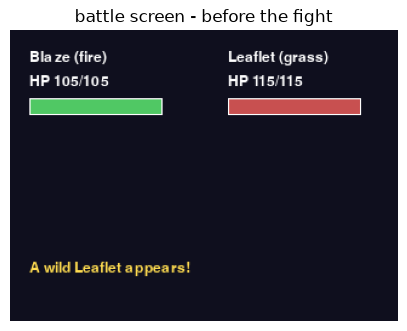

A battle begins: Blaze vs wild Leaflet!
Blaze used Ember! Leaflet takes 45 damage. It's super effective! (Leaflet HP 70/115)
Leaflet used Vine Whip! Blaze takes 12 damage. It's not very effective... (Blaze HP 93/105)
Blaze used Tackle! Leaflet takes 13 damage. (Leaflet HP 57/115)
Leaflet used Numbing Spores! Blaze takes 9 damage. It's not very effective... (Blaze HP 84/105)
round 3: a capture orb flies at wild Leaflet! (catch chance was 50%)
Argh, wild Leaflet broke free of the capture orb!
Leaflet used Vine Whip! Blaze takes 13 damage. It's not very effective... (Blaze HP 71/105)
Blaze used Tackle! Leaflet takes 16 damage. (Leaflet HP 41/115)
Leaflet used Numbing Spores! Blaze takes 5 damage. It's not very effective... (Blaze HP 66/105)
Blaze used Tackle! Leaflet takes 16 damage. (Leaflet HP 25/115)
Leaflet used Vine Whip! Blaze takes 10 damage. It's not very effective... (Blaze HP 56/105)
Blaze used Tackle! Leaflet takes 15 damage. (Leaflet HP 10/115)
Leaflet used Numbing Spores! Bla

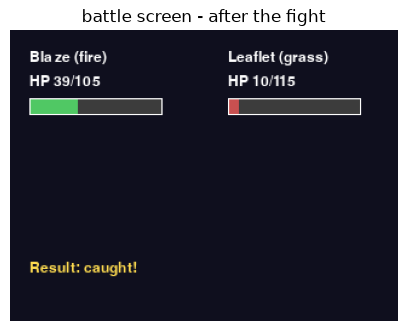

In [11]:
hero_creature = Creature(EMBERLING, moves=[EMBER, TACKLE], nickname="Blaze")
wild_creature = Creature(LEAFLET, moves=[VINE_WHIP, NUMBING_SPORES], nickname="Leaflet")

print("before the battle:")
print(" ", hero_creature)
print(" ", wild_creature)

show_surface(draw_battle_screen(hero_creature, wild_creature, "A wild Leaflet appears!"), title="battle screen - before the fight")

# a scripted plan: open with Ember (fire vs grass, should hit hard), weaken it with Tackle, then try a few catch attempts
scripted_actions = [
    ("move", "Ember"),
    ("move", "Tackle"),
    ("catch", None),
    ("move", "Tackle"),
    ("move", "Tackle"),
    ("move", "Tackle"),
    ("catch", None),
    ("catch", None),
    ("catch", None),
]

battle_log, battle_result = run_battle(hero_creature, scripted_actions, wild_creature)
for line in battle_log:
    print(line)
print("\nbattle result:", battle_result)

print("\nafter the battle:")
print(" ", hero_creature)
print(" ", wild_creature)

show_surface(draw_battle_screen(hero_creature, wild_creature, f"Result: {battle_result}!"), title="battle screen - after the fight")

## quick comparison to other languages
* a type-effectiveness-driven, turn-based, catch-a-creature battle system might be THE most cloned/reimplemented game mechanic by hobbyist programmers, in literally every language you can think of - search around and youll find "creature battle clone" style tutorials in JavaScript (very often built as a browser game with plain HTML/CSS for the battle screen), Java, C#/Unity, and Godot's GDScript, all solving the exact same three problems we just solved: a type chart lookup, speed-based turn order, and status effects
* the actual big commercial games in this genre were historically written in C for old handheld hardware, and modern entries use large proprietary engines - but the DESIGN PATTERN we used here (species/move data defined declaratively and kept completely separate from the battle LOGIC that reads it) is 100% language-agnostic
* in fact, bigger fan-made or original clone projects almost always take this separation one step further than we did: instead of hardcoding `CreatureSpecies`/`Move` instances directly in the source code like we just did, they load them from simple external data files (JSON or CSV) at runtime - so a designer can add a whole new creature or move without touching a single line of the battle code itself, regardless of what language that battle code happens to be written in

## Exercises
1. add a 5th `ElementType` called `ELECTRIC` to the chart (electric beats water 2x, is weak against grass 0.5x), create a `Sparkit` species and a `"Spark Shock"` move using it, then demonstrate its effectiveness against an existing type with `type_effectiveness()`
2. add a second status effect, `"burn"` - unlike paralysis it doesnt block a turn, it just chips away a bit of hp at the START of the burned creature's turn, every round, until it faints or the battle ends. write a small function for it and show it ticking down a creature's hp over a few rounds
3. call `attempt_catch()` at 3 different hp levels (high/medium/low, your choice of exact numbers) on a fresh creature and print the catch chance and outcome for each, so the "lower hp = easier catch" trend is clearly visible
4. give a creature a 3RD move (on top of its usual 2), then run a scripted 3-round battle where each round deliberately picks a DIFFERENT one of its 3 moves, and print what happens each round

In [12]:
# TODO: solve exercise 1 here (a 5th ELECTRIC type + Sparkit species + Spark Shock move, demonstrate its effectiveness)


# TODO: solve exercise 2 here (a "burn" status effect that chips away hp every round, demonstrate it over a few rounds)


# TODO: solve exercise 3 here (attempt_catch() at high/medium/low hp, print the chance + outcome for each)


# TODO: solve exercise 4 here (a creature with 3 moves, a scripted 3-round battle picking a different move each round)

### sample solutions
* try the exercises above yourself first, only look here if you are stuck or want to compare your approach

In [13]:
# sample solution 1 - a 5th type, ELECTRIC, plus a species and move that use it
class ElementTypeExtended(Enum):  # a separate enum here so we dont disturb the ElementType used everywhere above
    FIRE = "fire"
    WATER = "water"
    GRASS = "grass"
    NORMAL = "normal"
    ELECTRIC = "electric"  # our new 5th type

EXTENDED_TYPE_CHART = {
    ElementTypeExtended.FIRE: {ElementTypeExtended.GRASS: 2.0, ElementTypeExtended.WATER: 0.5},
    ElementTypeExtended.WATER: {ElementTypeExtended.FIRE: 2.0, ElementTypeExtended.GRASS: 0.5},
    ElementTypeExtended.GRASS: {ElementTypeExtended.WATER: 2.0, ElementTypeExtended.FIRE: 0.5},
    ElementTypeExtended.NORMAL: {},
    ElementTypeExtended.ELECTRIC: {ElementTypeExtended.WATER: 2.0, ElementTypeExtended.GRASS: 0.5},  # our new relationships
}

def extended_type_effectiveness(attacking_type, defending_type) -> float:
    return EXTENDED_TYPE_CHART.get(attacking_type, {}).get(defending_type, 1.0)

SPARKIT = CreatureSpecies("Sparkit", ElementTypeExtended.ELECTRIC, base_hp=85, base_attack=40, base_defense=30, base_speed=75)
SPARK_SHOCK = Move("Spark Shock", ElementTypeExtended.ELECTRIC, power=22, accuracy=0.9, status_effect="paralysis", status_chance=0.3)

print("Spark Shock vs water (Aqualing's type):", extended_type_effectiveness(ElementTypeExtended.ELECTRIC, ElementTypeExtended.WATER), "-> super effective!")
print("Spark Shock vs grass (Leaflet's type): ", extended_type_effectiveness(ElementTypeExtended.ELECTRIC, ElementTypeExtended.GRASS), "-> not very effective")


# sample solution 2 - a "burn" status that chips away hp at the start of each of the burned creature's turns
def apply_burn_damage(creature: Creature, burn_damage: int = 5) -> None:
    """Call this at the start of a burned creature's turn - a small guaranteed hit that ignores type/defense entirely."""
    if creature.status == "burn" and not creature.is_fainted:
        creature.take_damage(burn_damage)
        print(f"{creature.nickname} is hurt by its burn! HP: {creature.hp}/{creature.max_hp}")

burned_creature = Creature(AQUALING, moves=[AQUA_JET], nickname="Ripple")
burned_creature.status = "burn"
print("Ripple starts burned:", burned_creature)
for round_number in range(1, 4):  # simulate 3 rounds of a burn ticking away, on top of whatever else might happen that round
    print(f"-- round {round_number} --")
    apply_burn_damage(burned_creature)


# sample solution 3 - attempt_catch() at 3 hp levels, showing the "lower hp = easier catch" trend clearly
catch_exercise_target = Creature(ROCKLING, moves=[TACKLE], nickname="Boulder")
for label, hp_fraction in (("high", 0.9), ("medium", 0.5), ("low", 0.1)):
    catch_exercise_target.hp = max(1, int(catch_exercise_target.max_hp * hp_fraction))
    caught, chance = attempt_catch(catch_exercise_target)
    print(f"{label} hp ({catch_exercise_target.hp}/{catch_exercise_target.max_hp}): catch chance {chance:.0%}, result: {'caught!' if caught else 'broke free'}")


# sample solution 4 - a creature with 3 moves, a scripted 3-round battle deliberately using all 3
three_move_hero = Creature(EMBERLING, moves=[EMBER, TACKLE, AQUA_JET], nickname="Blaze")  # Aqua Jet as an "off-type" coverage move
practice_target = Creature(ROCKLING, moves=[TACKLE], nickname="Boulder")

three_move_actions = [("move", "Ember"), ("move", "Tackle"), ("move", "Aqua Jet")]  # one round per move, on purpose
three_move_log, three_move_result = run_battle(three_move_hero, three_move_actions, practice_target)
for line in three_move_log:
    print(line)
print("result:", three_move_result)

Spark Shock vs water (Aqualing's type): 2.0 -> super effective!
Spark Shock vs grass (Leaflet's type):  0.5 -> not very effective
Ripple starts burned: Ripple the Aqualing (Lv5 water-type, HP 110/110, status=burn)
-- round 1 --
Ripple is hurt by its burn! HP: 105/110
-- round 2 --
Ripple is hurt by its burn! HP: 100/110
-- round 3 --
Ripple is hurt by its burn! HP: 95/110
high hp (112/125): catch chance 18%, result: broke free
medium hp (62/125): catch chance 50%, result: broke free
low hp (12/125): catch chance 82%, result: caught!
A battle begins: Blaze vs wild Boulder!
Blaze used Ember! Boulder takes 22 damage. (Boulder HP 103/125)
Boulder used Tackle! Blaze takes 15 damage. (Blaze HP 90/105)
Blaze used Tackle! Boulder takes 12 damage. (Boulder HP 91/125)
Boulder used Tackle! Blaze takes 14 damage. (Blaze HP 76/105)
Blaze used Aqua Jet! Boulder takes 18 damage. (Boulder HP 73/125)
Boulder used Tackle! Blaze takes 13 damage. (Blaze HP 63/105)
Blaze used Ember! Boulder takes 21 damage

* congratulation you finished this lesson

## what we learned
* an `ElementType` `Enum` plus a small `TYPE_CHART` dict-of-dicts, and a `type_effectiveness()` lookup function with a sensible 1x default for any unlisted matchup
* `CreatureSpecies` and `Move` as `@dataclass`es - pure data blueprints, completely separate from the `Creature` class that actually battles with them
* a `Creature` class with stats derived from its species, an `is_fainted` property (this genre's take on lesson 32's `is_alive`), up to 4 known moves, and a `status` slot for effects like paralysis
* a damage formula that visibly changes based on type effectiveness - we proved the SAME move dealt very different damage against a weak-to-it target vs a resistant one
* `determine_turn_order()` - speed decides who acts first each round, a real improvement over lesson 32's always-player-first battles
* a full `run_battle()` loop: scripted `("move", name)` / `("catch", None)` / `("flee", None)` actions, a simple move-cycling enemy "AI", accuracy misses, and a paralysis status that can skip a creature's turn
* `attempt_catch()` - a catching mechanic where a weakened creature (lower current hp) is much easier to catch, an entirely new battle outcome (`"caught"`) lesson 32 never had
* a `Party` class and its `is_defeated` property - the real battle-loss condition for a whole team, not just a single character
* a battle screen rendered with pygame, reusing lesson 32's hp-bar technique and adding each creature's elemental type
* next up in lesson 38: we build the overworld, wild encounters and trainer battles ON TOP of everything from this lesson